<a href="https://colab.research.google.com/github/crreyes-unal/Reporte-problemas-MpAM/blob/main/Ejercicio3_SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

***Support Vector Machine: Problema de optimización asociado a cómo encontrar los mejores pesos para un SVM y desarrollarlo con optimización convexa***

Primero, se formula SVM como  un problema de optimización convexa.

El objetivo es encontrar un hiperplano $\mathbf{w}^T \mathbf{x} + b = 0$ que separe dos clases etiquetadas como $y_i \in \{-1, +1\}$ maximizando la distancia a los puntos más cercanos, mientras se penalizan los errores mediante variables $\xi_i$.

Dado un conjunto de entrenamiento $\mathcal{D} = \{(\mathbf{x}_i, y_i)\}_{i=1}^N$ con $\mathbf{x}_i \in \mathbb{R}^d$ se tiene

$$\min_{\mathbf{w}, b, \boldsymbol{\xi}} \frac{1}{2} \|\mathbf{w}\|_2^2 + C \sum_{i=1}^N \xi_i$$

$$\text{sujeto a} \quad y_i (\mathbf{w}^T \mathbf{x}_i + b) \ge 1 - \xi_i, \quad \xi_i \ge 0, \quad \forall i \in \{1, \dots, N\}$$

Donde $C > 0$ es el hiperparámetro de regularización que controla la tolerancia a errores de clasificación.

Ahora se verifica que el problema se puede resolver mediante optimización convexa. Primero, se verifica la función objetivo y el conjunto factible.

1. El término $\frac{1}{2} \|\mathbf{w}\|_2^2 = \frac{1}{2} \mathbf{w}^T \mathbf{I} \mathbf{w}$ es convexo porque su matriz Hessiana es la identidad $\nabla^2 (\frac{1}{2} \|\mathbf{w}\|_2^2) = \mathbf{I}_{d \times d}$, es definida positiva. El término $C \sum \xi_i$ es una función afín, por tanto convexa, sobre $\boldsymbol{\xi}$. La suma de funciones convexas preserva la convexidad. Así la función es convexa.

2. Las restricciones $1 - \xi_i - y_i(\mathbf{w}^T \mathbf{x}_i + b) \le 0$ y $-\xi_i \le 0$ son funciones afines sobre las variables de decisión $(\mathbf{w}, b, \boldsymbol{\xi})$. La intersección de un número finito de medioespacios cerrados define un poliedro convexo. Por tanto, el conjunto factible es convexo.
   
En consecuencia, al ser un problema de programación cuadrática convexo en $\mathbf{w}$, todo mínimo local es un mínimo global único en el espacio de pesos.

Ahora, al formular el Lagrangiano con multiplicadores $\alpha_i \ge 0$ y $\mu_i \ge 0$ se tiene

$$\mathcal{L}(\mathbf{w}, b, \boldsymbol{\xi}, \boldsymbol{\alpha}, \boldsymbol{\mu}) = \frac{1}{2}\|\mathbf{w}\|_2^2 + C \sum_{i=1}^N \xi_i - \sum_{i=1}^N \alpha_i \left[ y_i(\mathbf{w}^T \mathbf{x}_i + b) - 1 + \xi_i \right] - \sum_{i=1}^N \mu_i \xi_i$$

Como $\nabla_{\mathbf{w}} \mathcal{L} = 0$, $\frac{\partial \mathcal{L}}{\partial b} = 0$, se obtiene

$$\mathbf{w} = \sum_{i=1}^N \alpha_i y_i \mathbf{x}_i, \qquad \sum_{i=1}^N \alpha_i y_i = 0$$

Se usa el siguiente hecho $\alpha_i \left[ y_i(\mathbf{w}^T \mathbf{x}_i + b) - 1 + \xi_i \right] = 0$. Así, sólo los puntos para los cuales la restricción se activa con igualdad tienen multiplicador $\alpha_i > 0$, dichos puntos son los vectores de soporte.

Para este problema w es: [0.5775472  0.55504203] y b es: 0.0431


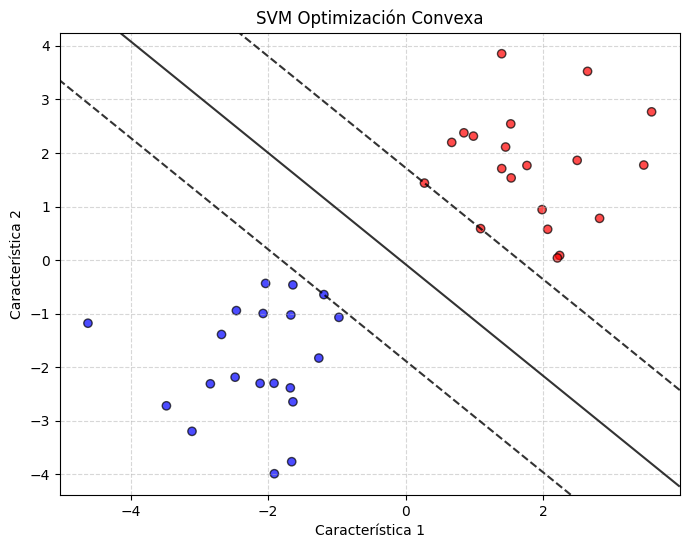

In [5]:
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt

# Usar clase para SVM

class ConvexSVM:
    """
    SVM Optimización convexa (Programación cuadrática) usando CVXPY
    """
    def __init__(self, C: float = 1.0):
        self.C = C
        self.w = None
        self.b = None
        self.dual_alphas = None

    def fit(self, X: np.ndarray, y: np.ndarray) -> None:
        N, d = X.shape
        y_vec = y.astype(np.float64)

        # Variables del hiperplano
        w = cp.Variable(d, name="w")
        b = cp.Variable(name="b")
        xi = cp.Variable(N, nonneg=True, name="xi")

        # Función objetivo convexa
        objective = cp.Minimize(0.5 * cp.sum_squares(w) + self.C * cp.sum(xi))

        # Restricciones afines
        constraints = [
            cp.multiply(y_vec, X @ w + b) >= 1 - xi
        ]

        # Condiciones del problema
        problem = cp.Problem(objective, constraints)
        problem.solve(solver=cp.OSQP, verbose=False)

        if problem.status not in ["optimal", "optimal_inaccurate"]:
            raise RuntimeError(f"El optimizador no convergió. Estado: {problem.status}")

        self.w = w.value
        self.b = b.value

        # Para obtener multiplicadores
        self.dual_alphas = constraints[0].dual_value

    def predict(self, X: np.ndarray) -> np.ndarray:
        """
        Calcula el signo de la función f(x) = w^T x + b
        """
        return np.sign(X @ self.w + self.b)

    def plot_decision_boundary(self, X: np.ndarray, y: np.ndarray):
        """
        Visualiza los datos, la frontera de decisión y los márgenes
        """
        if self.w is None or self.b is None:
            raise ValueError("El modelo debe ser entrenado antes de graficar")

        plt.figure(figsize=(8, 6))

        # Graficar los puntos de datos
        plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='k', alpha=0.7)

        ax = plt.gca()
        xlim = ax.get_xlim()
        ylim = ax.get_ylim()

        xx = np.linspace(xlim[0], xlim[1], 50)
        yy = np.linspace(ylim[0], ylim[1], 50)
        YY, XX = np.meshgrid(yy, xx)
        xy = np.vstack([XX.ravel(), YY.ravel()]).T

        # Evaluar la función de decisión f(x) = w^T x + b
        Z = (xy @ self.w + self.b).reshape(XX.shape)

        # Para dibujar los márgenes
        ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.8,
                   linestyles=['--', '-', '--'])

        # Para los títulos de la gráfica
        plt.title("SVM Optimización Convexa")
        plt.xlabel("Característica 1")
        plt.ylabel("Característica 2")
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.show()

# Verificación con un dataset particular
if __name__ == "__main__":
    np.random.seed(42)

    # Generación de datos
    X_pos = np.random.randn(20, 2) + np.array([2, 2])
    X_neg = np.random.randn(20, 2) + np.array([-2, -2])

    X_train = np.vstack([X_pos, X_neg])
    y_train = np.hstack([np.ones(20), -np.ones(20)])

    # Para justar el modelo
    svm = ConvexSVM(C=1.0)
    svm.fit(X_train, y_train)

    print(f"Para este problema w es: {svm.w} y b es: {svm.b:.4f}")
    svm.plot_decision_boundary(X_train, y_train)